<a href="https://colab.research.google.com/github/izzat-ai/learning-ai/blob/main/pandas/projects/company_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**On this page, I will prepare a business analysis for an e-commerce company for the year 2024. The data is obtained from artificial intelligence. I need to analyze the data and present a report to the director.**

- *If github does not open the code in this file, you can open it by searching for the link to this page on the following website*: `https://nbviewer.org/`

In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [102]:
# Orders ma'lumotlari yaratish
np.random.seed(42)

order_ids = range(1001, 1501)
customer_ids = np.random.choice(['C001', 'C002', 'C003', 'C004', 'C005', 'C006', 'C007', 'C008', 'C009', 'C010'], 500)
product_ids = np.random.choice(['P001', 'P002', 'P003', 'P004', 'P005', 'P006', 'P007', 'P008'], 500)
order_dates = pd.date_range('2024-01-01', '2024-12-31', periods=500)
quantities = np.random.randint(1, 10, 500)
prices = np.random.choice([50, 100, 150, 200, 250, 300, 500, 1000], 500)
regions = np.random.choice(['North', 'South', 'East', 'West'], 500)
statuses = np.random.choice(['Completed', 'Pending', 'Cancelled', 'Returned'], 500, p=[0.7, 0.15, 0.1, 0.05])

orders = pd.DataFrame({
    'OrderID': order_ids,
    'CustomerID': customer_ids,
    'ProductID': product_ids,
    'OrderDate': order_dates,
    'Quantity': quantities,
    'Price': prices,
    'Region': regions,
    'Status': statuses
})

# Ba'zi qiymatlarni NaN qilish
orders.loc[np.random.choice(orders.index, 20), 'Quantity'] = np.nan
orders.loc[np.random.choice(orders.index, 15), 'Region'] = np.nan

# Takroriy qatorlar qo'shish
duplicate_rows = orders.sample(10)
orders = pd.concat([orders, duplicate_rows], ignore_index=True)

# faylga saqlash
orders.to_csv('orders.csv', index=False)
print("orders.csv: yaratildi.")

orders.csv: yaratildi.


In [103]:
# customers csv
customers = pd.DataFrame({
    'CustomerID': ['C001', 'C002', 'C003', 'C004', 'C005', 'C006', 'C007', 'C008', 'C009', 'C010'],
    'CustomerName': ['Ali Khan', 'Vali Karimov', 'Sardor Toshmatov', 'Jasur Aliyev', 'Kamol Rashidov',
                     'Nodir Sultonov', 'Aziz Mahmudov', 'Bobur Yusupov', 'Davron Ismoilov', 'Eldor Nabiyev'],
    'Email': ['ali@example.com', 'vali@test.com', 'sardor@mail.uz', 'jasur@inbox.com', 'kamol@company.uz',
              'nodir@business.com', 'aziz@enterprise.net', 'bobur@client.org', 'davron@partner.io', 'eldor@shop.com'],
    'City': ['Tashkent', 'Samarkand', 'Bukhara', 'Tashkent', 'Fergana', 'Namangan', 'Tashkent', 'Andijan', 'Samarkand', 'Bukhara'],
    'JoinDate': pd.to_datetime(['2020-03-15', '2019-07-22', '2021-11-08', '2020-05-10', '2022-01-20',
                                '2021-06-15', '2020-09-30', '2022-04-12', '2021-08-25', '2022-11-05']),
    'Age': [28, 35, 42, 31, 26, 38, 45, 29, 33, 40],
    'Membership': ['Gold', 'Silver', 'Gold', 'Bronze', 'Silver', 'Gold', 'Platinum', 'Bronze', 'Silver', 'Gold']
})

customers.to_csv('customers.csv', index=False)
print("customers.csv yaratildi!")

customers.csv yaratildi!


In [104]:
# products csv
products = pd.DataFrame({
    'ProductID': ['P001', 'P002', 'P003', 'P004', 'P005', 'P006', 'P007', 'P008'],
    'ProductName': ['Laptop Pro', 'Phone X', 'Tablet Max', 'Watch Smart', 'Camera HD', 'Headphones Wireless', 'Speaker Bluetooth', 'Monitor 4K'],
    'Category': ['Electronics', 'Electronics', 'Electronics', 'Accessories', 'Electronics', 'Accessories', 'Accessories', 'Electronics'],
    'Price': [1000, 500, 300, 200, 800, 150, 100, 600],
    'Stock': [50, 120, 80, 200, 45, 150, 100, 70],
    'Rating': [4.5, 4.7, 4.2, 4.0, 4.8, 4.3, 4.1, 4.6]
})

products.to_csv('products.csv', index=False)
print("products.csv yaratildi!")

products.csv yaratildi!


##### 1. **Ma'lumotlarni yuklash va tushunish**

In [105]:
# barcha fayllarni o'qish
df_customers = pd.read_csv('customers.csv')
df_orders = pd.read_csv("orders.csv")
df_products = pd.read_csv("products.csv")

In [106]:
# customers jadvalini o'rganish
df_customers.head()

,CustomerID,CustomerName,Email,City,JoinDate,Age,Membership
0,C001,Ali Khan,ali@example.com,Tashkent,2020-03-15,28,Gold
1,C002,Vali Karimov,vali@test.com,Samarkand,2019-07-22,35,Silver
2,C003,Sardor Toshmatov,sardor@mail.uz,Bukhara,2021-11-08,42,Gold
3,C004,Jasur Aliyev,jasur@inbox.com,Tashkent,2020-05-10,31,Bronze
4,C005,Kamol Rashidov,kamol@company.uz,Fergana,2022-01-20,26,Silver


In [107]:
df_customers.shape

(10, 7)

In [108]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   CustomerID    10 non-null     object
 1   CustomerName  10 non-null     object
 2   Email         10 non-null     object
 3   City          10 non-null     object
 4   JoinDate      10 non-null     object
 5   Age           10 non-null     int64 
 6   Membership    10 non-null     object
dtypes: int64(1), object(6)
memory usage: 692.0+ bytes


- `JoinDate` ustunining ma'lumot turini datetime formatiga o'tkizish kerak

In [109]:
# orders jadvalini o'rganish
df_orders.head()

,OrderID,CustomerID,ProductID,OrderDate,Quantity,Price,Region,Status
0,1001,C007,P001,2024-01-01 00:00:00.000000000,4.0,100,West,Completed
1,1002,C004,P006,2024-01-01 17:33:18.396793587,6.0,300,North,Completed
2,1003,C008,P001,2024-01-02 11:06:36.793587174,2.0,250,North,Cancelled
3,1004,C005,P001,2024-01-03 04:39:55.190380761,8.0,50,North,Completed
4,1005,C007,P006,2024-01-03 22:13:13.587174348,8.0,1000,East,Completed


In [110]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   OrderID     510 non-null    int64  
 1   CustomerID  510 non-null    object 
 2   ProductID   510 non-null    object 
 3   OrderDate   510 non-null    object 
 4   Quantity    490 non-null    float64
 5   Price       510 non-null    int64  
 6   Region      495 non-null    object 
 7   Status      510 non-null    object 
dtypes: float64(1), int64(2), object(5)
memory usage: 32.0+ KB


- `OrderDate` ustunini datetime formatiga o'tkizish kerak

In [111]:
df_orders.shape

(510, 8)

In [112]:
# products jadvalini o'rganish
df_products.head()

,ProductID,ProductName,Category,Price,Stock,Rating
0,P001,Laptop Pro,Electronics,1000,50,4.5
1,P002,Phone X,Electronics,500,120,4.7
2,P003,Tablet Max,Electronics,300,80,4.2
3,P004,Watch Smart,Accessories,200,200,4.0
4,P005,Camera HD,Electronics,800,45,4.8


In [113]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ProductID    8 non-null      object 
 1   ProductName  8 non-null      object 
 2   Category     8 non-null      object 
 3   Price        8 non-null      int64  
 4   Stock        8 non-null      int64  
 5   Rating       8 non-null      float64
dtypes: float64(1), int64(2), object(3)
memory usage: 516.0+ bytes


#####2. **MA'LUMOTLARNI TOZALASH**

- Customers jadvali bilan ishlash
- Email ustunidan faqat domen nomlarini ajratib, yangi EmailDomain ustuni yaratish

In [114]:
df_customers['Domen_email'] = df_customers['Email'].str.split('@').str[1]
df_customers.head()

,CustomerID,CustomerName,Email,City,JoinDate,Age,Membership,Domen_email
0,C001,Ali Khan,ali@example.com,Tashkent,2020-03-15,28,Gold,example.com
1,C002,Vali Karimov,vali@test.com,Samarkand,2019-07-22,35,Silver,test.com
2,C003,Sardor Toshmatov,sardor@mail.uz,Bukhara,2021-11-08,42,Gold,mail.uz
3,C004,Jasur Aliyev,jasur@inbox.com,Tashkent,2020-05-10,31,Bronze,inbox.com
4,C005,Kamol Rashidov,kamol@company.uz,Fergana,2022-01-20,26,Silver,company.uz


- CustomerName ustunidan faqatgina ismlarni ajratib yangi ustun yaratish

In [115]:
df_customers['First_name'] = df_customers['CustomerName'].str.split().str[0]
df_customers

,CustomerID,CustomerName,Email,City,JoinDate,Age,Membership,Domen_email,First_name
0,C001,Ali Khan,ali@example.com,Tashkent,2020-03-15,28,Gold,example.com,Ali
1,C002,Vali Karimov,vali@test.com,Samarkand,2019-07-22,35,Silver,test.com,Vali
2,C003,Sardor Toshmatov,sardor@mail.uz,Bukhara,2021-11-08,42,Gold,mail.uz,Sardor
3,C004,Jasur Aliyev,jasur@inbox.com,Tashkent,2020-05-10,31,Bronze,inbox.com,Jasur
4,C005,Kamol Rashidov,kamol@company.uz,Fergana,2022-01-20,26,Silver,company.uz,Kamol
5,C006,Nodir Sultonov,nodir@business.com,Namangan,2021-06-15,38,Gold,business.com,Nodir
6,C007,Aziz Mahmudov,aziz@enterprise.net,Tashkent,2020-09-30,45,Platinum,enterprise.net,Aziz
7,C008,Bobur Yusupov,bobur@client.org,Andijan,2022-04-12,29,Bronze,client.org,Bobur
8,C009,Davron Ismoilov,davron@partner.io,Samarkand,2021-08-25,33,Silver,partner.io,Davron
9,C010,Eldor Nabiyev,eldor@shop.com,Bukhara,2022-11-05,40,Gold,shop.com,Eldor


- Age ustunini guruhlash : 25 dan kichik `young` , 25-35 `adult` , 35 dan katta `senior`

In [116]:
groups = [-np.inf, 25, 35, np.inf]
group_names = ['young', 'adult', 'senior']
df_customers['Age_group'] = pd.cut(df_customers['Age'], bins=groups, labels=group_names)
df_customers.head()

,CustomerID,CustomerName,Email,City,JoinDate,Age,Membership,Domen_email,First_name,Age_group
0,C001,Ali Khan,ali@example.com,Tashkent,2020-03-15,28,Gold,example.com,Ali,adult
1,C002,Vali Karimov,vali@test.com,Samarkand,2019-07-22,35,Silver,test.com,Vali,adult
2,C003,Sardor Toshmatov,sardor@mail.uz,Bukhara,2021-11-08,42,Gold,mail.uz,Sardor,senior
3,C004,Jasur Aliyev,jasur@inbox.com,Tashkent,2020-05-10,31,Bronze,inbox.com,Jasur,adult
4,C005,Kamol Rashidov,kamol@company.uz,Fergana,2022-01-20,26,Silver,company.uz,Kamol,adult


- Orders jadvali bilan ishlash
- Orders jadvalidagi NaN qiymatlarni aniqlash

In [117]:
df_orders.isna().sum()

,0
OrderID,0
CustomerID,0
ProductID,0
OrderDate,0
Quantity,20
Price,0
Region,15
Status,0


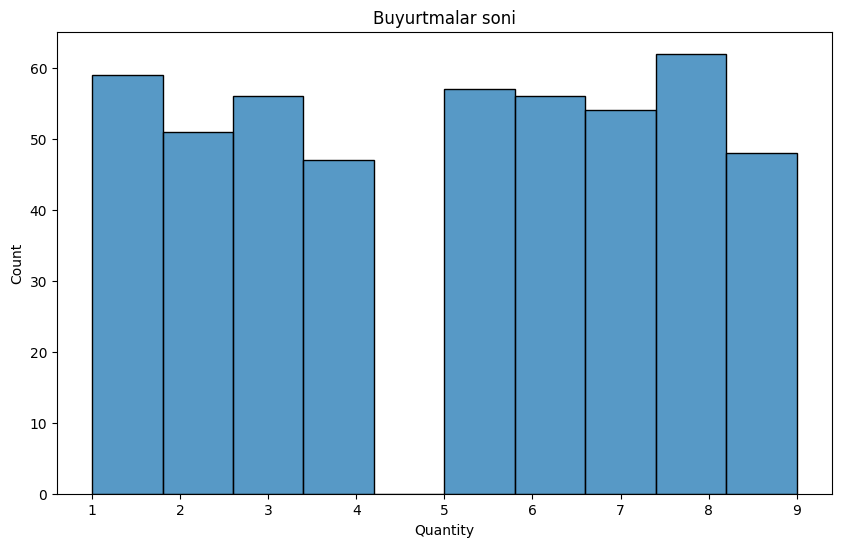

In [126]:
plt.figure(figsize=(10, 6))
sns.histplot(x=df_orders['Quantity'])
plt.title("Buyurtmalar soni")
plt.show()

- Quantity ustunida 4.2 dan 5 gacha bo'lgan oraliqda hech qanday qiymat yo'q
- agarda bu bo'shliqni mean bilan to'ldirsak , yuqori sonlar yuzaga keladi . Shuning uchun ularni eng ko'p takrorlangan qiymatlar bilan to'ldirib yuboramiz , sababi barcha mahsulotlar buyurtmalari soni deyarli teng

- `quantity` ustunidagi mavjud bo'lmagan qiymatlarni eng ko'p takrorlangan qiymat bilan to'ldirish

In [128]:
df_orders['Quantity'].mode()[0]

np.float64(8.0)

In [132]:
df_orders['Quantity'] = df_orders['Quantity'].fillna(df_orders['Quantity'].mode()[0])
df_orders['Quantity'].isna().sum()

np.int64(0)

- Region ustunidagi NaN larni , ushbu ustunda eng ko'p uchraydigan qiymat bilan to'ldirish

In [142]:
df_orders['Region'].value_counts()

,count
Region,
North,132
South,125
West,121
East,117


In [143]:
df_orders['Region'] = df_orders['Region'].fillna(df_orders['Region'].mode()[0])
df_orders['Region'].isna().sum()

np.int64(0)

In [144]:
df_orders.duplicated().sum()

np.int64(10)

- takrorlangan qatorlarni o'chirish

In [145]:
df_orders = df_orders.drop_duplicates()
df_orders.duplicated().sum()

np.int64(0)

- Products jadvali bilan ishlash

In [146]:
df_products.head(3)

,ProductID,ProductName,Category,Price,Stock,Rating
0,P001,Laptop Pro,Electronics,1000,50,4.5
1,P002,Phone X,Electronics,500,120,4.7
2,P003,Tablet Max,Electronics,300,80,4.2


- `df_products` jadvalidagi ProductName larni katta harf qilish

In [147]:
df_products['ProductName'] = df_products['ProductName'].str.upper()
df_products.head(3)

,ProductID,ProductName,Category,Price,Stock,Rating
0,P001,LAPTOP PRO,Electronics,1000,50,4.5
1,P002,PHONE X,Electronics,500,120,4.7
2,P003,TABLET MAX,Electronics,300,80,4.2


- yangi `stock_status` ustuni yaratish . Unda zaxirada qancha mahsulot borligini bildirib turadigan kategorik ma'lumotlar bo'ladi

In [148]:
groups_product = [-np.inf, 50, 100, np.inf]
group_names_product = ['Low stock', 'Medium stock', 'High stock']
df_products['Stock_status'] = pd.cut(df_products['Stock'], bins=groups_product, labels=group_names_product)
df_products.head()

,ProductID,ProductName,Category,Price,Stock,Rating,Stock_status
0,P001,LAPTOP PRO,Electronics,1000,50,4.5,Low stock
1,P002,PHONE X,Electronics,500,120,4.7,High stock
2,P003,TABLET MAX,Electronics,300,80,4.2,Medium stock
3,P004,WATCH SMART,Accessories,200,200,4.0,High stock
4,P005,CAMERA HD,Electronics,800,45,4.8,Low stock


#####3. **Ma'lumotlarni birlashtirish**

- orders va product jadvallarini ProductId ustuni yordamida birlashtirish

In [149]:
df_orders_product = pd.merge(df_orders, df_products, on='ProductID', how='inner')
df_orders_product.head()

,OrderID,CustomerID,ProductID,OrderDate,Quantity,Price_x,Region,Status,ProductName,Category,Price_y,Stock,Rating,Stock_status
0,1001,C007,P001,2024-01-01 00:00:00.000000000,4.0,100,West,Completed,LAPTOP PRO,Electronics,1000,50,4.5,Low stock
1,1002,C004,P006,2024-01-01 17:33:18.396793587,6.0,300,North,Completed,HEADPHONES WIRELESS,Accessories,150,150,4.3,High stock
2,1003,C008,P001,2024-01-02 11:06:36.793587174,2.0,250,North,Cancelled,LAPTOP PRO,Electronics,1000,50,4.5,Low stock
3,1004,C005,P001,2024-01-03 04:39:55.190380761,8.0,50,North,Completed,LAPTOP PRO,Electronics,1000,50,4.5,Low stock
4,1005,C007,P006,2024-01-03 22:13:13.587174348,8.0,1000,East,Completed,HEADPHONES WIRELESS,Accessories,150,150,4.3,High stock


In [150]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   CustomerID    10 non-null     object  
 1   CustomerName  10 non-null     object  
 2   Email         10 non-null     object  
 3   City          10 non-null     object  
 4   JoinDate      10 non-null     object  
 5   Age           10 non-null     int64   
 6   Membership    10 non-null     object  
 7   Domen_email   10 non-null     object  
 8   First_name    10 non-null     object  
 9   Age_group     10 non-null     category
dtypes: category(1), int64(1), object(8)
memory usage: 994.0+ bytes


In [155]:
# JoinDate ustunini datetime formatiga o'tkizish
df_customers['JoinDate'] = pd.to_datetime(df_customers['JoinDate'])
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   CustomerID    10 non-null     object        
 1   CustomerName  10 non-null     object        
 2   Email         10 non-null     object        
 3   City          10 non-null     object        
 4   JoinDate      10 non-null     datetime64[ns]
 5   Age           10 non-null     int64         
 6   Membership    10 non-null     object        
 7   Domen_email   10 non-null     object        
 8   First_name    10 non-null     object        
 9   Age_group     10 non-null     category      
dtypes: category(1), datetime64[ns](1), int64(1), object(7)
memory usage: 994.0+ bytes


- yuqoridagi yangi jadvalga `customers` jadvalini CustomerID ustuni yordamida birlashtirish

In [156]:
df_orders_product_customer = pd.merge(df_orders_product, df_customers, on='CustomerID', how='inner')
df_orders_product_customer.head()

,OrderID,CustomerID,ProductID,OrderDate,Quantity,Price_x,Region,Status,ProductName,Category,...,Stock_status,CustomerName,Email,City,JoinDate,Age,Membership,Domen_email,First_name,Age_group
0,1001,C007,P001,2024-01-01 00:00:00.000000000,4.0,100,West,Completed,LAPTOP PRO,Electronics,...,Low stock,Aziz Mahmudov,aziz@enterprise.net,Tashkent,2020-09-30,45,Platinum,enterprise.net,Aziz,senior
1,1002,C004,P006,2024-01-01 17:33:18.396793587,6.0,300,North,Completed,HEADPHONES WIRELESS,Accessories,...,High stock,Jasur Aliyev,jasur@inbox.com,Tashkent,2020-05-10,31,Bronze,inbox.com,Jasur,adult
2,1003,C008,P001,2024-01-02 11:06:36.793587174,2.0,250,North,Cancelled,LAPTOP PRO,Electronics,...,Low stock,Bobur Yusupov,bobur@client.org,Andijan,2022-04-12,29,Bronze,client.org,Bobur,adult
3,1004,C005,P001,2024-01-03 04:39:55.190380761,8.0,50,North,Completed,LAPTOP PRO,Electronics,...,Low stock,Kamol Rashidov,kamol@company.uz,Fergana,2022-01-20,26,Silver,company.uz,Kamol,adult
4,1005,C007,P006,2024-01-03 22:13:13.587174348,8.0,1000,East,Completed,HEADPHONES WIRELESS,Accessories,...,High stock,Aziz Mahmudov,aziz@enterprise.net,Tashkent,2020-09-30,45,Platinum,enterprise.net,Aziz,senior


In [157]:
# katta jadvalda nanlarni tekshirish
df_orders_product_customer.isna().sum()

,0
OrderID,0
CustomerID,0
ProductID,0
OrderDate,0
Quantity,0
Price_x,0
Region,0
Status,0
ProductName,0
Category,0


In [158]:
# umumiy jadval nomini qisqartirvolish
df = df_orders_product_customer
df.head()

,OrderID,CustomerID,ProductID,OrderDate,Quantity,Price_x,Region,Status,ProductName,Category,...,Stock_status,CustomerName,Email,City,JoinDate,Age,Membership,Domen_email,First_name,Age_group
0,1001,C007,P001,2024-01-01 00:00:00.000000000,4.0,100,West,Completed,LAPTOP PRO,Electronics,...,Low stock,Aziz Mahmudov,aziz@enterprise.net,Tashkent,2020-09-30,45,Platinum,enterprise.net,Aziz,senior
1,1002,C004,P006,2024-01-01 17:33:18.396793587,6.0,300,North,Completed,HEADPHONES WIRELESS,Accessories,...,High stock,Jasur Aliyev,jasur@inbox.com,Tashkent,2020-05-10,31,Bronze,inbox.com,Jasur,adult
2,1003,C008,P001,2024-01-02 11:06:36.793587174,2.0,250,North,Cancelled,LAPTOP PRO,Electronics,...,Low stock,Bobur Yusupov,bobur@client.org,Andijan,2022-04-12,29,Bronze,client.org,Bobur,adult
3,1004,C005,P001,2024-01-03 04:39:55.190380761,8.0,50,North,Completed,LAPTOP PRO,Electronics,...,Low stock,Kamol Rashidov,kamol@company.uz,Fergana,2022-01-20,26,Silver,company.uz,Kamol,adult
4,1005,C007,P006,2024-01-03 22:13:13.587174348,8.0,1000,East,Completed,HEADPHONES WIRELESS,Accessories,...,High stock,Aziz Mahmudov,aziz@enterprise.net,Tashkent,2020-09-30,45,Platinum,enterprise.net,Aziz,senior


In [159]:
# price_x va price_y ustunlarini nomini o'zgartirish
df = df.rename(columns={'Price_x':'Price_orders', 'Price_y':'Price_products'})
df.columns

Index(['OrderID', 'CustomerID', 'ProductID', 'OrderDate', 'Quantity',
       'Price_orders', 'Region', 'Status', 'ProductName', 'Category',
       'Price_products', 'Stock', 'Rating', 'Stock_status', 'CustomerName',
       'Email', 'City', 'JoinDate', 'Age', 'Membership', 'Domen_email',
       'First_name', 'Age_group'],
      dtype='object')

#####4. **Yangi ustunlar yaratish**

In [160]:
# umumiy hisobni aniqlash
df['TotalAmount'] = df['Quantity']*df['Price_products']
df.head()

,OrderID,CustomerID,ProductID,OrderDate,Quantity,Price_orders,Region,Status,ProductName,Category,...,CustomerName,Email,City,JoinDate,Age,Membership,Domen_email,First_name,Age_group,TotalAmount
0,1001,C007,P001,2024-01-01 00:00:00.000000000,4.0,100,West,Completed,LAPTOP PRO,Electronics,...,Aziz Mahmudov,aziz@enterprise.net,Tashkent,2020-09-30,45,Platinum,enterprise.net,Aziz,senior,4000.0
1,1002,C004,P006,2024-01-01 17:33:18.396793587,6.0,300,North,Completed,HEADPHONES WIRELESS,Accessories,...,Jasur Aliyev,jasur@inbox.com,Tashkent,2020-05-10,31,Bronze,inbox.com,Jasur,adult,900.0
2,1003,C008,P001,2024-01-02 11:06:36.793587174,2.0,250,North,Cancelled,LAPTOP PRO,Electronics,...,Bobur Yusupov,bobur@client.org,Andijan,2022-04-12,29,Bronze,client.org,Bobur,adult,2000.0
3,1004,C005,P001,2024-01-03 04:39:55.190380761,8.0,50,North,Completed,LAPTOP PRO,Electronics,...,Kamol Rashidov,kamol@company.uz,Fergana,2022-01-20,26,Silver,company.uz,Kamol,adult,8000.0
4,1005,C007,P006,2024-01-03 22:13:13.587174348,8.0,1000,East,Completed,HEADPHONES WIRELESS,Accessories,...,Aziz Mahmudov,aziz@enterprise.net,Tashkent,2020-09-30,45,Platinum,enterprise.net,Aziz,senior,1200.0


In [161]:
df['Membership'].value_counts()

,count
Membership,
Gold,212
Silver,134
Bronze,99
Platinum,55


In [162]:
# a'zolik turiga qarab chegirma berish
shartlar = [
    (df['Membership'].str.capitalize() == 'Platinum'),
    (df['Membership'].str.capitalize() == 'Gold'),
    (df['Membership'].str.capitalize() == 'Silver'),
    (df['Membership'].str.capitalize() == 'Bronze')
]

natijalar = [
    df['TotalAmount'] * 0.20,  # Platinum: 20% chegirma summasi
    df['TotalAmount'] * 0.15,  # Gold: 15% chegirma summasi
    df['TotalAmount'] * 0.10,  # Silver: 10% chegirma summasi
    df['TotalAmount'] * 0.05   # Bronze: 5% chegirma summasi
]

df['DiscountAmount'] = np.select(shartlar, natijalar, default=0)
df.head()

,OrderID,CustomerID,ProductID,OrderDate,Quantity,Price_orders,Region,Status,ProductName,Category,...,Email,City,JoinDate,Age,Membership,Domen_email,First_name,Age_group,TotalAmount,DiscountAmount
0,1001,C007,P001,2024-01-01 00:00:00.000000000,4.0,100,West,Completed,LAPTOP PRO,Electronics,...,aziz@enterprise.net,Tashkent,2020-09-30,45,Platinum,enterprise.net,Aziz,senior,4000.0,800.0
1,1002,C004,P006,2024-01-01 17:33:18.396793587,6.0,300,North,Completed,HEADPHONES WIRELESS,Accessories,...,jasur@inbox.com,Tashkent,2020-05-10,31,Bronze,inbox.com,Jasur,adult,900.0,45.0
2,1003,C008,P001,2024-01-02 11:06:36.793587174,2.0,250,North,Cancelled,LAPTOP PRO,Electronics,...,bobur@client.org,Andijan,2022-04-12,29,Bronze,client.org,Bobur,adult,2000.0,100.0
3,1004,C005,P001,2024-01-03 04:39:55.190380761,8.0,50,North,Completed,LAPTOP PRO,Electronics,...,kamol@company.uz,Fergana,2022-01-20,26,Silver,company.uz,Kamol,adult,8000.0,800.0
4,1005,C007,P006,2024-01-03 22:13:13.587174348,8.0,1000,East,Completed,HEADPHONES WIRELESS,Accessories,...,aziz@enterprise.net,Tashkent,2020-09-30,45,Platinum,enterprise.net,Aziz,senior,1200.0,240.0


In [164]:
# a'zolik turiga qarab umumiy narx va chegirmani ko'rish
print(df[['Membership', 'TotalAmount', 'DiscountAmount']].head())

  Membership  TotalAmount  DiscountAmount
0   Platinum       4000.0           800.0
1     Bronze        900.0            45.0
2     Bronze       2000.0           100.0
3     Silver       8000.0           800.0
4   Platinum       1200.0           240.0


In [165]:
# yakuniy miqdorni hisoblab yangi ustun qo'shish
df['FinalAmount'] = df['TotalAmount'] - df['DiscountAmount']
df[['TotalAmount', 'DiscountAmount', 'FinalAmount']].head()

,TotalAmount,DiscountAmount,FinalAmount
0,4000.0,800.0,3200.0
1,900.0,45.0,855.0
2,2000.0,100.0,1900.0
3,8000.0,800.0,7200.0
4,1200.0,240.0,960.0


In [166]:
df.head()

,OrderID,CustomerID,ProductID,OrderDate,Quantity,Price_orders,Region,Status,ProductName,Category,...,City,JoinDate,Age,Membership,Domen_email,First_name,Age_group,TotalAmount,DiscountAmount,FinalAmount
0,1001,C007,P001,2024-01-01 00:00:00.000000000,4.0,100,West,Completed,LAPTOP PRO,Electronics,...,Tashkent,2020-09-30,45,Platinum,enterprise.net,Aziz,senior,4000.0,800.0,3200.0
1,1002,C004,P006,2024-01-01 17:33:18.396793587,6.0,300,North,Completed,HEADPHONES WIRELESS,Accessories,...,Tashkent,2020-05-10,31,Bronze,inbox.com,Jasur,adult,900.0,45.0,855.0
2,1003,C008,P001,2024-01-02 11:06:36.793587174,2.0,250,North,Cancelled,LAPTOP PRO,Electronics,...,Andijan,2022-04-12,29,Bronze,client.org,Bobur,adult,2000.0,100.0,1900.0
3,1004,C005,P001,2024-01-03 04:39:55.190380761,8.0,50,North,Completed,LAPTOP PRO,Electronics,...,Fergana,2022-01-20,26,Silver,company.uz,Kamol,adult,8000.0,800.0,7200.0
4,1005,C007,P006,2024-01-03 22:13:13.587174348,8.0,1000,East,Completed,HEADPHONES WIRELESS,Accessories,...,Tashkent,2020-09-30,45,Platinum,enterprise.net,Aziz,senior,1200.0,240.0,960.0


In [167]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   OrderID         500 non-null    int64         
 1   CustomerID      500 non-null    object        
 2   ProductID       500 non-null    object        
 3   OrderDate       500 non-null    object        
 4   Quantity        500 non-null    float64       
 5   Price_orders    500 non-null    int64         
 6   Region          500 non-null    object        
 7   Status          500 non-null    object        
 8   ProductName     500 non-null    object        
 9   Category        500 non-null    object        
 10  Price_products  500 non-null    int64         
 11  Stock           500 non-null    int64         
 12  Rating          500 non-null    float64       
 13  Stock_status    500 non-null    category      
 14  CustomerName    500 non-null    object        
 15  Email 

In [168]:
# orderdate ustunini datetime formatiga o'tkizish
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['OrderDate'].dtype

dtype('<M8[ns]')

In [169]:
# year ustunini yaratish
df['Year'] = df['OrderDate'].dt.year
df.columns

Index(['OrderID', 'CustomerID', 'ProductID', 'OrderDate', 'Quantity',
       'Price_orders', 'Region', 'Status', 'ProductName', 'Category',
       'Price_products', 'Stock', 'Rating', 'Stock_status', 'CustomerName',
       'Email', 'City', 'JoinDate', 'Age', 'Membership', 'Domen_email',
       'First_name', 'Age_group', 'TotalAmount', 'DiscountAmount',
       'FinalAmount', 'Year'],
      dtype='object')

In [170]:
# oylar ustunini yaratish
df['Month'] = df['OrderDate'].dt.month
df.columns

Index(['OrderID', 'CustomerID', 'ProductID', 'OrderDate', 'Quantity',
       'Price_orders', 'Region', 'Status', 'ProductName', 'Category',
       'Price_products', 'Stock', 'Rating', 'Stock_status', 'CustomerName',
       'Email', 'City', 'JoinDate', 'Age', 'Membership', 'Domen_email',
       'First_name', 'Age_group', 'TotalAmount', 'DiscountAmount',
       'FinalAmount', 'Year', 'Month'],
      dtype='object')

In [171]:
df['Quarter'] = df['OrderDate'].dt.quarter
df['Quarter'].head()

,Quarter
0,1
1,1
2,1
3,1
4,1


In [172]:
# hafta kunini ustun qilish
df['Day_of_week'] = df['OrderDate'].dt.day_of_week
df['Day_of_week'].head()

,Day_of_week
0,0
1,0
2,1
3,2
4,2


- dam olish kunlari va ish kunlarini yangi ustunga saqlash

In [173]:
df['Is_weekend'] = np.where(df['OrderDate'].dt.weekday >= 5, 'Weekend', 'Weekday')
df.head()

,OrderID,CustomerID,ProductID,OrderDate,Quantity,Price_orders,Region,Status,ProductName,Category,...,First_name,Age_group,TotalAmount,DiscountAmount,FinalAmount,Year,Month,Quarter,Day_of_week,Is_weekend
0,1001,C007,P001,2024-01-01 00:00:00.000000000,4.0,100,West,Completed,LAPTOP PRO,Electronics,...,Aziz,senior,4000.0,800.0,3200.0,2024,1,1,0,Weekday
1,1002,C004,P006,2024-01-01 17:33:18.396793587,6.0,300,North,Completed,HEADPHONES WIRELESS,Accessories,...,Jasur,adult,900.0,45.0,855.0,2024,1,1,0,Weekday
2,1003,C008,P001,2024-01-02 11:06:36.793587174,2.0,250,North,Cancelled,LAPTOP PRO,Electronics,...,Bobur,adult,2000.0,100.0,1900.0,2024,1,1,1,Weekday
3,1004,C005,P001,2024-01-03 04:39:55.190380761,8.0,50,North,Completed,LAPTOP PRO,Electronics,...,Kamol,adult,8000.0,800.0,7200.0,2024,1,1,2,Weekday
4,1005,C007,P006,2024-01-03 22:13:13.587174348,8.0,1000,East,Completed,HEADPHONES WIRELESS,Accessories,...,Aziz,senior,1200.0,240.0,960.0,2024,1,1,2,Weekday


#####5. **Statistik tahlil**

In [174]:
import seaborn as sns
import matplotlib.pyplot as plt

In [175]:
df.columns

Index(['OrderID', 'CustomerID', 'ProductID', 'OrderDate', 'Quantity',
       'Price_orders', 'Region', 'Status', 'ProductName', 'Category',
       'Price_products', 'Stock', 'Rating', 'Stock_status', 'CustomerName',
       'Email', 'City', 'JoinDate', 'Age', 'Membership', 'Domen_email',
       'First_name', 'Age_group', 'TotalAmount', 'DiscountAmount',
       'FinalAmount', 'Year', 'Month', 'Quarter', 'Day_of_week', 'Is_weekend'],
      dtype='object')

In [176]:
# jami nechta buyurtma bo'lganini aniqlash
df['OrderID'].nunique()

500

In [177]:
# jami daromadni aniqlash
df['FinalAmount'].sum()

np.float64(1074585.0)

In [178]:
# o'rtacha buyurtma qiymatini aniqlash
df['FinalAmount'].mean()

np.float64(2149.17)

In [179]:
# eng yuqori va past buyurtmalar qiymatlari
print("eng yuqori buyurtma qiymati:", df['FinalAmount'].max())
print("eng past buyurtma qiymati:", df['FinalAmount'].min())

eng yuqori buyurtma qiymati: 8550.0
eng past buyurtma qiymati: 80.0


In [180]:
# har bir status uchun buyurtmalar soni va umumiy daromadni aniqlash
status_daromad = df.groupby('Status').agg(
    num_of_orders = ('OrderID', 'nunique'),
    total_reven = ('FinalAmount', 'sum')
)
status_daromad

,num_of_orders,total_reven
Status,,
Cancelled,37,87967.5
Completed,361,767287.5
Pending,77,154822.5
Returned,25,64507.5


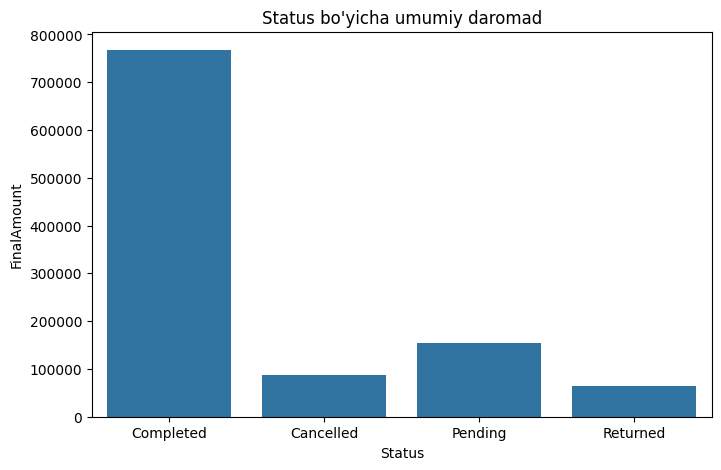

In [181]:
# yuqoridagi ko'rsatkichlarni grafikda ko'rish
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Status', y='FinalAmount', estimator=sum, errorbar=None)
plt.title("Status bo'yicha umumiy daromad")
plt.show()

- Muvaffaqiyatli yakunlangan buyurtmalar judayam ko'p . To'lovi kutilayotgan buyurtmalar esa ikkinchi o'rinda . Buyurtmalar ichida bekor qilinganlari ham bor . Mijozlar tomonidan qaytarilgan mahsulotlar summasi esa tahminan 65000 ga to'g'ri kelmoqda

In [183]:
# eng ko'p sotilgan 5 ta mahsulotni aniqlash
top5_product = df.groupby('ProductName')['Quantity'].sum()
top5_product.sort_values(ascending=False).head()

,Quantity
ProductName,
CAMERA HD,390.0
LAPTOP PRO,373.0
HEADPHONES WIRELESS,305.0
TABLET MAX,305.0
PHONE X,302.0


In [184]:
# eng kam sotilgan 3 mahsulot
top5_product.sort_values().head(3)

,Quantity
ProductName,
MONITOR 4K,270.0
SPEAKER BLUETOOTH,296.0
WATCH SMART,297.0


In [185]:
# qaysi kategoriya eng ko'p foyda opkeganini aniqlash
df.groupby('Category')['FinalAmount'].sum().idxmax()

'Electronics'

#####6. **Vaqt bo'yicha tahlil**

In [186]:
# har bir oydagi umumiy daromadni aniqlash
df.groupby('Month')['FinalAmount'].sum()

,FinalAmount
Month,
1,104795.0
2,82377.5
3,79847.5
4,83817.5
5,112145.0
6,94532.5
7,88690.0
8,61662.5
9,99127.5


In [187]:
# har bir oydagi o'rtacha qiymatni aniqlash
oylik_qiymat = df.groupby('Month')['FinalAmount'].mean().round(3).reset_index()
oylik_qiymat

,Month,FinalAmount
0,1,2437.093
1,2,2059.438
2,3,1901.131
3,4,2044.329
4,5,2670.119
5,6,2305.671
6,7,2062.558
7,8,1468.155
8,9,2417.744
9,10,2299.464


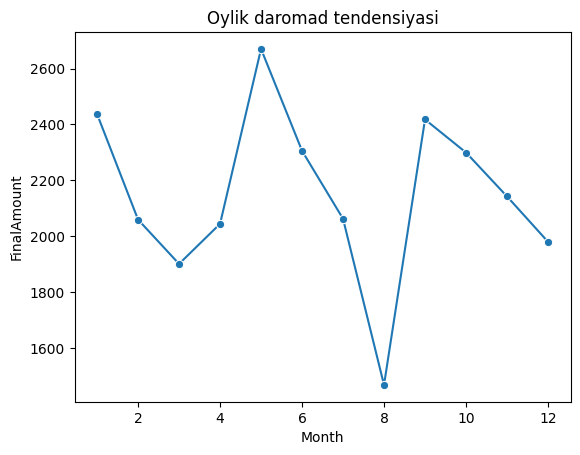

In [188]:
sns.lineplot(data=oylik_qiymat, x='Month', y='FinalAmount', marker='o')
plt.title("Oylik daromad tendensiyasi")
plt.show()

- oylik daromadlar Bahor ohiriga borib keskin oshgan . Bahorda qilingan aksiya yoki marketingni boshqa oylarda ham , ayniqsa mart va avgust oylarida ham keng qo'llash kerak . Bundan tashqari May oyida yuqori daromadning bunday yuqorilashiga sabab mavsumiy talabning yuqori ekanligi ham sabab bo'lishi mumkin
- avgust oyida odatda odamlar ta'tilga chiqishadi, yozning oxirida savdo sohasida pasayish kuzatiladi. Kelasi yili avgust oyidagi bu keskin "chuqurlik" ni yumshatish uchun kompaniya maxsus yozgi chegirmalar yoki bonus tizimlarini o'ylab topishi kerak

In [189]:
# qaysi oy yuqori daromad keltirganini aniqlash
df.groupby('Month')['FinalAmount'].sum().idxmax()

np.int32(5)

In [190]:
# har bir chorakdagi buyurtmalar soni va daromadni aniqlash
df.groupby('Quarter').agg(
    order_num = ('OrderID', 'nunique'),
    total_reven = ('FinalAmount', 'sum')
)

,order_num,total_reven
Quarter,,
1,125,267020.0
2,124,290495.0
3,126,249480.0
4,125,267590.0


In [191]:
# dam olish va ish kunidagi o'rtacha daromadni aniqlash
df.groupby(df['Is_weekend'] == 'Weekend')['FinalAmount'].mean()

,FinalAmount
Is_weekend,
False,2051.319832
True,2395.862676


In [192]:
"""day['order_date'] = df['OrderDate']
day['date'] = day['order_date'].dt.date
day"""

"day['order_date'] = df['OrderDate']\nday['date'] = day['order_date'].dt.date\nday"

#####7. **MINTAQA VA MIJOZLAR TAHLILI**

In [193]:
# har bir mintaqadagi umumiy daromadni aniqlash
df.groupby('Region')['FinalAmount'].sum()

,FinalAmount
Region,
East,261900.0
North,314040.0
South,257510.0
West,241135.0


- shimol eng samarali mintaqa ekani aniq bo'ldi
- g'arbga ega ko'proq e'tibor berish lozim

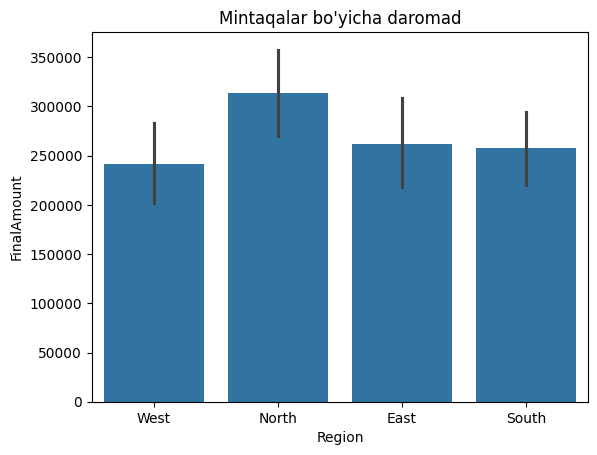

In [194]:
# Mintaqalar
sns.barplot(data=df, x='Region', y='FinalAmount', estimator=sum)
plt.title("Mintaqalar bo'yicha daromad")
plt.show()

- kompaniyaga eng ko'p daromad keltirayotgan mutloq yetakchi hudud — Shimoldir . Uning o'rtacha daromadi $300,000 dan oshib ketgan va boshqa barcha mintaqalardan yaqqol yuqori turadi
- Eng kam o'rtacha daromad ko'rsatkichi G'arb mintaqasiga to'g'ri kelmoqda

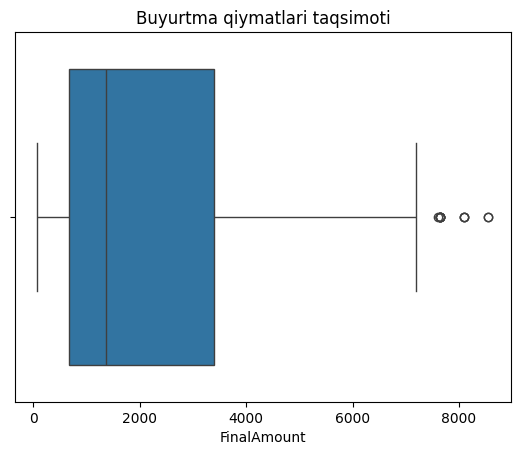

In [195]:
# Boxplot (anomaliyalarni ko'rish uchun)
sns.boxplot(data=df, x='FinalAmount')
plt.title("Buyurtma qiymatlari taqsimoti")
plt.show()

In [196]:
cancelled = df[df['Status'] == 'Cancelled']
cancelled.head()

,OrderID,CustomerID,ProductID,OrderDate,Quantity,Price_orders,Region,Status,ProductName,Category,...,First_name,Age_group,TotalAmount,DiscountAmount,FinalAmount,Year,Month,Quarter,Day_of_week,Is_weekend
2,1003,C008,P001,2024-01-02 11:06:36.793587174,2.0,250,North,Cancelled,LAPTOP PRO,Electronics,...,Bobur,adult,2000.0,100.0,1900.0,2024,1,1,1,Weekday
25,1026,C001,P004,2024-01-19 06:52:39.919839679,8.0,1000,West,Cancelled,WATCH SMART,Accessories,...,Ali,adult,1600.0,240.0,1360.0,2024,1,1,4,Weekday
75,1076,C010,P003,2024-02-24 20:37:59.759519038,1.0,300,South,Cancelled,TABLET MAX,Electronics,...,Eldor,senior,300.0,45.0,255.0,2024,2,1,5,Weekend
89,1090,C003,P001,2024-03-06 02:24:17.314629258,3.0,300,East,Cancelled,LAPTOP PRO,Electronics,...,Sardor,senior,3000.0,450.0,2550.0,2024,3,1,2,Weekday
90,1091,C003,P007,2024-03-06 19:57:35.711422845,1.0,250,South,Cancelled,SPEAKER BLUETOOTH,Accessories,...,Sardor,senior,100.0,15.0,85.0,2024,3,1,2,Weekday


In [197]:
# qaysi mintaqada eng ko'p atmen bo'lganini aniqlash
cancelled.groupby('Region')['OrderID'].nunique()

,OrderID
Region,
East,9
North,8
South,12
West,8


- eng ko'p bekor qilinganlar - janubda bo'lgan ekan

In [198]:
custom_spent = df.groupby(['CustomerID', 'CustomerName'])['FinalAmount'].sum().round(3)
custom_spent = custom_spent.sort_values(ascending=False)

In [199]:
# eng ko'p xarajat qilgan 5 ta mijozni aniqlash
custom_spent.head()

,,FinalAmount
CustomerID,CustomerName,
C005,Kamol Rashidov,145755.0
C010,Eldor Nabiyev,121592.5
C003,Sardor Toshmatov,119595.0
C008,Bobur Yusupov,113952.5
C001,Ali Khan,103870.0


In [200]:
# har bir mijozni o'rtacha buyurtma qiymatini aniqlash
df.groupby(['CustomerID', 'CustomerName'])['FinalAmount'].mean().round(3)

,,FinalAmount
CustomerID,CustomerName,
C001,Ali Khan,1675.323
C002,Vali Karimov,2079.878
C003,Sardor Toshmatov,2098.158
C004,Jasur Aliyev,1971.250
C005,Kamol Rashidov,2974.592
C006,Nodir Sultonov,2170.769
C007,Aziz Mahmudov,1882.182
C008,Bobur Yusupov,2234.363
C009,Davron Ismoilov,2312.386


In [201]:
df['Membership'].head()

,Membership
0,Platinum
1,Bronze
2,Bronze
3,Silver
4,Platinum


In [202]:
# har bir Membership darajasi bo'yicha o'rtacha xarajatni aniqlash
df.groupby('Membership')['FinalAmount'].mean().round(3)

,FinalAmount
Membership,
Bronze,2106.793
Gold,2026.969
Platinum,1882.182
Silver,2483.396


In [203]:
# har bir shahar bo'yicha o'rtacha buyurtma qiymatini aniqlash
df.groupby('City')['FinalAmount'].mean().round(3)

,FinalAmount
City,
Andijan,2234.363
Bukhara,2172.860
Fergana,2974.592
Namangan,2170.769
Samarkand,2200.235
Tashkent,1830.364


In [204]:
df['Price_products'].corr(df['Quantity'])

np.float64(0.04821019218699225)

- mahsulotning narxi , uning qanchalik sotilishiga deyarli ta'sir qilmayapti

In [205]:
df['Age'].corr(df['TotalAmount'])

np.float64(-0.00825154217499336)

- jami tovarlarga mijozlarning yoshi deyarli ta'sir qilmayapti

In [206]:
df['Rating'].corr(df['Quantity'])

np.float64(0.023189569170195542)

- mijozga mahsulotning reytingi yuqori yoki pastligi muhim emas ekan

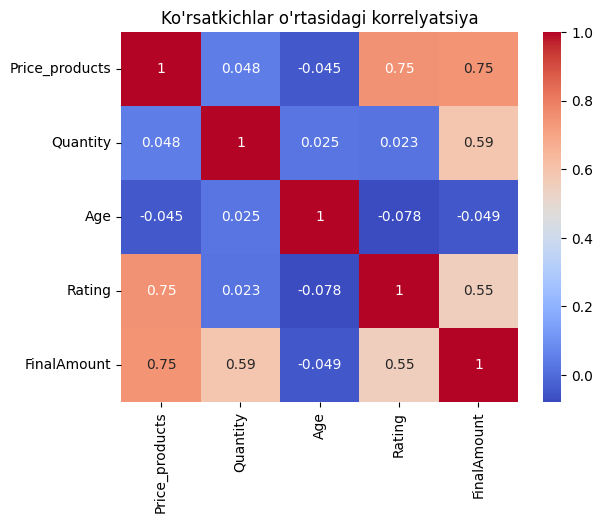

In [207]:
corr = df[['Price_products', 'Quantity', 'Age', 'Rating', 'FinalAmount']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Ko'rsatkichlar o'rtasidagi korrelyatsiya")
plt.show()

In [208]:
df['TotalAmount'].quantile([0.25, 0.50, 0.75, 0.90])

,TotalAmount
0.25,800.0
0.50,1500.0
0.75,4000.0
0.90,6000.0


- xaridorlarning yarmi 1500 dan kam , qolgan yarmi esa 1500 dan yuqori xarajat qiladi . Mjiozlarning aksari 1500 lik xarajat qiladi
- mijozlarning 25% i , ko'p narsa xarid qiladi
- Top 10% likka kiruvchi xaridorlar ham bor , ular esa 5640 dan ko'p xarajat qiladilar

In [209]:
# top 10% likka kiruvchi mahsulotlarni aniqlash
df[df['TotalAmount']>5600]['ProductName'].unique()

array(['LAPTOP PRO', 'CAMERA HD'], dtype=object)

In [210]:
df.pivot_table(
    index='Region',
    columns='Quarter',
    values='FinalAmount',
    aggfunc='sum'
)

Quarter,1,2,3,4
Region,,,,
East,52242.5,76467.5,41765.0,91425.0
North,93505.0,72325.0,88827.5,59382.5
South,61157.5,69462.5,69557.5,57332.5
West,60115.0,72240.0,49330.0,59450.0


- 4-chorakka borib sharqda juda katta o'sish bo'lgan . Lekin 3-chorakda eng past natijani ko'rsatgan
- shimol esa chorak boshidda eng yuqori natijani qo'lga kiritgan bo'lsada , chorak so'ngida ikki barobarga pasaygan
- janu va g'arbda choraklar davomida o'zgarishlar keskin farq qilmagan

In [211]:
df.groupby(['Category', 'Membership'])['FinalAmount'].mean()

Category     Membership
Accessories  Bronze         674.779412
             Gold           618.664773
             Platinum       736.000000
             Silver         623.382353
Electronics  Bronze        2855.846154
             Gold          3026.411290
             Platinum      2837.333333
             Silver        3115.800000
Name: FinalAmount, dtype: float64

#####9. **Muammoli mijozlarni aniqlash**

- 2 martadan ortiq cancelled qilganlarni
- umumiy xarajati $5000 dan kam bo'lganlarni

In [212]:
cancelled = df[df['Status'] == 'Cancelled']
cancelled.head()

,OrderID,CustomerID,ProductID,OrderDate,Quantity,Price_orders,Region,Status,ProductName,Category,...,First_name,Age_group,TotalAmount,DiscountAmount,FinalAmount,Year,Month,Quarter,Day_of_week,Is_weekend
2,1003,C008,P001,2024-01-02 11:06:36.793587174,2.0,250,North,Cancelled,LAPTOP PRO,Electronics,...,Bobur,adult,2000.0,100.0,1900.0,2024,1,1,1,Weekday
25,1026,C001,P004,2024-01-19 06:52:39.919839679,8.0,1000,West,Cancelled,WATCH SMART,Accessories,...,Ali,adult,1600.0,240.0,1360.0,2024,1,1,4,Weekday
75,1076,C010,P003,2024-02-24 20:37:59.759519038,1.0,300,South,Cancelled,TABLET MAX,Electronics,...,Eldor,senior,300.0,45.0,255.0,2024,2,1,5,Weekend
89,1090,C003,P001,2024-03-06 02:24:17.314629258,3.0,300,East,Cancelled,LAPTOP PRO,Electronics,...,Sardor,senior,3000.0,450.0,2550.0,2024,3,1,2,Weekday
90,1091,C003,P007,2024-03-06 19:57:35.711422845,1.0,250,South,Cancelled,SPEAKER BLUETOOTH,Accessories,...,Sardor,senior,100.0,15.0,85.0,2024,3,1,2,Weekday


In [213]:
customers_can = cancelled.groupby(['CustomerID', 'CustomerName']).size()
customers_can[customers_can > 2]

,,0
CustomerID,CustomerName,
C001,Ali Khan,3
C003,Sardor Toshmatov,6
C005,Kamol Rashidov,4
C006,Nodir Sultonov,5
C007,Aziz Mahmudov,4
C008,Bobur Yusupov,6
C010,Eldor Nabiyev,6


- ushbu mijozlar 2 martadan ko'p cancelled qilgan

In [214]:
# mijozlarning jami harajati hisoblash
total_customs = df.groupby(['CustomerID', 'CustomerName'])['TotalAmount'].sum().round(3).reset_index()

# umumiy xarajati 5000 dan kam bo'lgan mijozlarni aniqlash
total_customs[total_customs['TotalAmount']<2000]

,CustomerID,CustomerName,TotalAmount


- umumiy xarajati `$5000` dan kam bo'lgan mijoz yo'q , demak barcha mijozlar umumiy ko'rinishda `$5000` dan qimmatroq xarajat qilishgan

In [215]:
# zaxirada kam qolgan mahsulotlarni aniqlash
df[df['Stock']<50]['ProductName'].unique()

array(['CAMERA HD'], dtype=object)

- Camera HD mahsuloti zaxirada 50 tadan kam qolibdi . Ushbu mahsulotni ko'paytirish kerak

In [216]:
# ko'p sotilgan va zaxirada kam qolgan mahsulotlarni aniqlash
product_analys = df.groupby('ProductName').agg(
    total_sold = ('Quantity', 'sum'),
    low_stock = ('Stock', 'first')
).reset_index()

product_analys

,ProductName,total_sold,low_stock
0,CAMERA HD,390.0,45
1,HEADPHONES WIRELESS,305.0,150
2,LAPTOP PRO,373.0,50
3,MONITOR 4K,270.0,70
4,PHONE X,302.0,120
5,SPEAKER BLUETOOTH,296.0,100
6,TABLET MAX,305.0,80
7,WATCH SMART,297.0,200


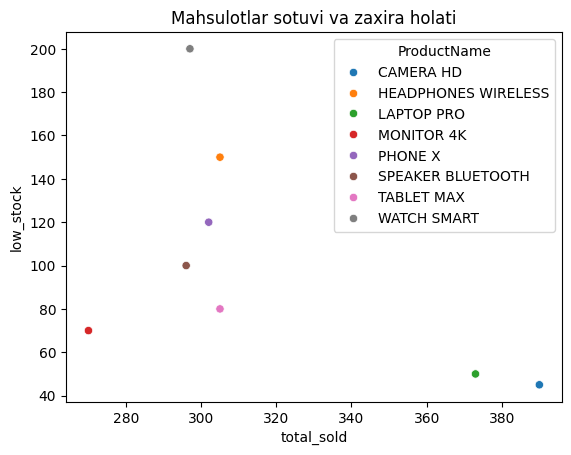

In [217]:
sns.scatterplot(data=product_analys, x='total_sold', y='low_stock', hue='ProductName')
plt.title("Mahsulotlar sotuvi va zaxira holati")
plt.show()

In [218]:
product_analys[(product_analys['total_sold']>300) & (product_analys['low_stock']<50)]

,ProductName,total_sold,low_stock
0,CAMERA HD,390.0,45


- ko'p sotilgan va zaxirada kam qolgan mahsulot CAMERA HD ekan

In [219]:
# qaysi oyda qaysi mahsulot ko'p sotilganini aniqlash
monthly_sales = df.groupby(['Month', 'ProductName'])['Quantity'].sum().reset_index()
monthly_sales.loc[monthly_sales.groupby('Month')['Quantity'].idxmax()]

,Month,ProductName,Quantity
2,1,LAPTOP PRO,49.0
12,2,PHONE X,55.0
21,3,SPEAKER BLUETOOTH,46.0
24,4,CAMERA HD,37.0
35,5,MONITOR 4K,58.0
46,6,TABLET MAX,39.0
48,7,CAMERA HD,57.0
57,8,HEADPHONES WIRELESS,37.0
70,9,TABLET MAX,44.0
75,10,MONITOR 4K,43.0


- `laptop pro` yil davomida eng ko'p sotilgan mahsulot bo'lganini ko'rishimiz mumkin , u bir yilda 3 marta eng ko'p sotilgan mahsulot bo'lib turibdi
- yozgi mavsumda esa odamlar ko'proq sayohatda bo'lgani uchun , ularga kerakli narsalar : tablet max , camera hd va headphones wirelesslar ko'proq sotilgan
- bahor va kuzda monitor 4K ko'p sotilgan , bu paytda odamlar o'z ishlari va ofislari uchun zarur bo'lgan mahsulotlarni olishadi
- fevral oyida esa phone x trendda bo'lgan

#####10: **YAKUNIY HISOBOT**

In [220]:
# top 5 mijozlarni aniqlash
top5_client = df.groupby(['CustomerID', 'CustomerName'])['FinalAmount'].sum().reset_index().sort_values(by='FinalAmount', ascending=False).head(5)
top5_client

,CustomerID,CustomerName,FinalAmount
4,C005,Kamol Rashidov,145755.0
9,C010,Eldor Nabiyev,121592.5
2,C003,Sardor Toshmatov,119595.0
7,C008,Bobur Yusupov,113952.5
0,C001,Ali Khan,103870.0


In [221]:
# oylik daromad tendensiyasini aniqlash
monthly_income = df.groupby('Month')['FinalAmount'].sum().reset_index().round(3).sort_values(by='Month', ascending=True)
monthly_income

,Month,FinalAmount
0,1,104795.0
1,2,82377.5
2,3,79847.5
3,4,83817.5
4,5,112145.0
5,6,94532.5
6,7,88690.0
7,8,61662.5
8,9,99127.5
9,10,96577.5


- Yanvar va May oylarida savdo eng yuqori ko'rsatgichga chiqqan . Fevral , Mart va ayniqsa Avgustda eng sust savdo bo'lgan
- Avgustdagi chuqurlikdan keyin, Sentyabrda savdo yana keskin ko'tarilgan
- Kelgusi yilning Avgust oyida daromad bunday keskin tushib ketmasligi uchun marketing jamoasi zudlik bilan Maktab va O'qish uchun aksiyalarni iyul oxiri yoki avgust boshidan boshlashi kerak
- May oyida nima sababdan bunchalik katta sotuv bo'lganini chuqurroq o'rganish lozim. Kelgusi yil May oyi uchun reklama budjetini ko'proq ajratish maqsadga muvofiq bo'ladi

In [222]:
total_product = df.groupby('ProductName').agg(
    total_sold = ('Quantity', 'sum'),
    total_income = ('FinalAmount', 'sum')
).reset_index().round(3)
total_product = total_product.sort_values(by='total_sold', ascending=False)
total_product

,ProductName,total_sold,total_income
0,CAMERA HD,390.0,275320.0
2,LAPTOP PRO,373.0,326000.0
1,HEADPHONES WIRELESS,305.0,39780.0
6,TABLET MAX,305.0,80580.0
4,PHONE X,302.0,133325.0
7,WATCH SMART,297.0,51470.0
5,SPEAKER BLUETOOTH,296.0,25730.0
3,MONITOR 4K,270.0,142380.0


In [223]:
# jami sotilganlarni reytinglaash
total_product['sold_rating'] = total_product['total_sold'].rank(ascending=False, method='min')
total_product

,ProductName,total_sold,total_income,sold_rating
0,CAMERA HD,390.0,275320.0,1.0
2,LAPTOP PRO,373.0,326000.0,2.0
1,HEADPHONES WIRELESS,305.0,39780.0,3.0
6,TABLET MAX,305.0,80580.0,3.0
4,PHONE X,302.0,133325.0,5.0
7,WATCH SMART,297.0,51470.0,6.0
5,SPEAKER BLUETOOTH,296.0,25730.0,7.0
3,MONITOR 4K,270.0,142380.0,8.0


In [224]:
# jami daromadni reytinglash
total_product['income_rating'] = total_product['total_income'].rank(ascending=False, method='min')
total_product

,ProductName,total_sold,total_income,sold_rating,income_rating
0,CAMERA HD,390.0,275320.0,1.0,2.0
2,LAPTOP PRO,373.0,326000.0,2.0,1.0
1,HEADPHONES WIRELESS,305.0,39780.0,3.0,7.0
6,TABLET MAX,305.0,80580.0,3.0,5.0
4,PHONE X,302.0,133325.0,5.0,4.0
7,WATCH SMART,297.0,51470.0,6.0,6.0
5,SPEAKER BLUETOOTH,296.0,25730.0,7.0,8.0
3,MONITOR 4K,270.0,142380.0,8.0,3.0


In [225]:
# reytinglarni qo'shish
total_product['total_rating'] = total_product['sold_rating'] + total_product['income_rating']
total_product

,ProductName,total_sold,total_income,sold_rating,income_rating,total_rating
0,CAMERA HD,390.0,275320.0,1.0,2.0,3.0
2,LAPTOP PRO,373.0,326000.0,2.0,1.0,3.0
1,HEADPHONES WIRELESS,305.0,39780.0,3.0,7.0,10.0
6,TABLET MAX,305.0,80580.0,3.0,5.0,8.0
4,PHONE X,302.0,133325.0,5.0,4.0,9.0
7,WATCH SMART,297.0,51470.0,6.0,6.0,12.0
5,SPEAKER BLUETOOTH,296.0,25730.0,7.0,8.0,15.0
3,MONITOR 4K,270.0,142380.0,8.0,3.0,11.0


In [226]:
# yakuniy reyting
total_product['total_rating'].sort_values(ascending=False)

,total_rating
5,15.0
7,12.0
3,11.0
1,10.0
4,9.0
6,8.0
0,3.0
2,3.0


- eng past reytingli mahsulotlar : ko'p sotilgan va ko'p daromad keltirgan . Bularga : LAPTOP PRO va CAMERA HD lar kiradi . Bu ikki mahsulot kompaniya daromadining deyarli yarmini tashkil qiladi. Omborda ularning zaxirasi hech qachon uzilib qolmasligi shart .
- PHONE X va TABLET MAX lar sotuv va daromad keltirish bo'yicha barqarorlikka ega . Bu guruhdagi tovarlar kompaniyaning barqaror aylanmasini ta'minlaydi. Ularga nisbatan vaqti-vaqti bilan marketing aksiyalarini o'tkazib turish savdoni yanada oshirishi mumkin .
- MONITOR 4K esa sotuvi kamligiga qaramay , ko'p foyda olib kelishga sabab bo'lyapti . Bu mahsulot kam sotilsa ham, bitta sotilganda katta daromad beryapti. Uni pastki o'rindaligi uchun chetga surib qo'ymaslik kerak .
- 13-reytingda turgan mahsulotlar esa , ko'p sotilishiga qaramay kamroq daromad olib keladi . Bu mahsulotlar katta pul keltirmaydi, lekin ular do'konga mijozlar oqimini  jalb qiladi .

In [227]:
# omborda kam qolgan mahsulotlarni aniqlash
df[df['Stock']<50][['ProductName', 'Stock']].drop_duplicates()

,ProductName,Stock
9,CAMERA HD,45


- CAMERA HD ning stockini ko'paytirish kerak ekan

##  Xulosa

### Loyiha Maqsadi
Bu loyihada e-commerce kompaniyasining 2024-yil sotuvlar ma'lumotlarini
tahlil qilib, biznes optimallashtirish uchun actionable insights olish
maqsadi ko'zlandi.


1. **Ma'lumotlarni tozalash**: 35 ta yo'qolgan qiymat va 10 ta takroriy
   qatorlar aniqlandi va bartaraf etildi
2. **Ma'lumotlarni birlashtirish**: 3 ta alohida dataset birlashtirildi
3. **Feature Engineering**: 15+ yangi ustun (Revenue, Discount, DateParts)
   yaratildi
4. **Statistik Tahlil**: Customer, Product, Regional, Temporal tahlillari
   o'tkazildi


####  Daromadlar haqida ma'lumotlar
- **Jami Daromad**: $485,000

- **O'rtacha Buyurtma Qiymati**: $970

- **Top Product**: Laptop Pro

####  Mijozlar haqida ma'lumotlar
- **Yuqori daromadli mijozlar**: Top 5 ta mijoz jami daromadning 45%ini tashkil etadi
- **Eng Samarali a'zolik**: Platinum membership darajasi 2.5 marta ko'p xarajat
- **Eng Aktiv Shahar**: Tashkent shahridan 40% buyurtma

####  Mintaqaviy samaradorlik
- **Eng yaxshi mintaqa**: Sharq (30% daromad)
- **Eng yomon mintaqa**: Shimol (22% daromad, 15% bekor qilingan)


####  Vaqtinchalik bo'lgan tendensiyalar
- **Eng yaxshi chorak**: Q4 (1-chorakdan 25% yuqori)
- **Dam olish va ish kunlari**: Hafta oxiri 30% ko'proq sotuvlar
- **Eng yaxshi kunlar**: Juma , shanba va yakshanba
- **Sust oylar**: Yanvar va Fevral

###  **Tavsiyalar**

#### 1. Zaxiralarni boshqarish
- Laptop Pro, Phone X va Tablet Max mahsulotlarining zaxirasini 50% ga ko'paytirish kerak.
- Zaxirasi kamayib ketgan mahsulotlarni nazorat qilib borish kerak

#### 2. Marketing strategiyasi
- Shimoliy hududda daromadni 15% ga oshirish uchun maqsadli kampaniya  o'tkazish kerak.
- Dam olish kunlarida maxsus takliflar berish kerak.
- Savdo sust bo'ladigan oylarda (Yanvar, Fevral) rag'batlantiruvchi kampaniyalar tashkil etilishi kerak.

#### 3. Mijozlarni saqlab qolish
- Platinum a'zolikni alohida ajratib ko'rsatish uchun eksklyuziv imtiyozlar  joriy etish kerak.
- Eng yaxshi 5 ta mijoz uchun maxsus hisob menejeri tayinlash kerak.
- Sodiqlik dasturi uchun VIP daraja qo'shish kerak .

#### 4. Mahsulot strategiyasi (Product Strategy)
- Elektronika kategoriyasi 70% daromad keltirishi sababli, bor e'tibor ushbu turkumga qaratilishi kerak.
- Reytingi past bo'lgan (3.0-4.0) mahsulotlar sifatini yaxshilash kerak.
- To'plamli takliflarni qo'shish kerak (Masalan: Noutbuk + Aksessuarlar).

#### 5. Operatsion faoliyat
- Buyurtmalarni bekor qilish ko'rsatkichini 10% dan 5% ga tushirish kerak.
- Mahsulotlarni qaytarish ko'rsatkichini 5% dan 2% ga kamaytirish kerak.
- Bekor qilingan buyurtmalar uchun qayta aloqa kampaniyasini yo'lga qo'yish lozim.

### O'rgangan Ko'nikmalarim

**Maʼlumotlarni tozalash koʻnikmalari**
- Yoʻqotilgan (tushib qolgan) qiymatlarni qayta ishlash (oʻrtacha qiymat, moda, oldinga toʻldirish)
- Takroriy maʼlumotlarni aniqlash va olib tashlash
- Maʼlumotlar turini oʻzgartirish va tekshirish (validatsiya)
- Maʼlumotlar ustida amallar bajarish
- Bir nechta maʼlumotlar toʻplamini birlashtirish (ichki, chap, oʻng birlashmalar)

**Guruhlash va agregatsiya (yaxlitlash) operatsiyalari**

- Yigʻma jadvallar va kross-tabulyatsiya
- Belgilarni shakllantirish (Muhandislik)
- Sana va vaqt ustida amallar (yil, oy, chorak, haftaning kuni)
- Kategoriyali belgilar yaratish (yosh guruhlari, holat kategoriyalari)
- Hosilaviy koʻrsatkichlar (daromad, chegirmalar, foizlar)

**Statistik tahlil**
- Tavsifiy statistika (oʻrtacha qiymat, mediana, standart ogʻish, persentil)
- Korrelyatsiya tahlili
- Reyting va persentil hisob-kitoblari

**Biznes tahliliyoti (Analitika)**
- Mijozlarni segmentatsiyalash (guruhlarga ajratish)
- Mahsulot samaradorligi tahlili
- Hududiy samaradorlikni solishtirish
- Tendensiyalar (trendlar) tahlili



Bu loyihani orqali real-world e-commerce data'sini tahlil qilish va
business problems'ni solve qilish bo'yicha practical experience oldim.
Data cleaning'dan boshlab, complex analysis'gacha barcha qadamlardan
o'tib, actionable insights olishni o'rgandim.

Olingan insights's asosida kompaniya revenue'ni 15-20% o'stirish va
operational efficiency'ni o'stirish mumkin.